# 01 — Load & Validate PVGIS Climate Data
**APV-AD Project | Step 1 of 7**

This notebook:
1. Parses the four PVGIS-SARAH3 TMY CSV files
2. Validates the data (completeness, physical plausibility, no NaN)
3. Extracts growing-season windows per site
4. Computes seasonal ET₀ (Hargreaves-Samani) — used as water savings denominator
5. Saves one clean DataFrame per site to `outputs/csv/hourly_SITE.csv`
6. Prints a summary table for quick verification

**Run time:** < 30 seconds  
**Output:** `hourly_Konya.csv`, `hourly_Almeria.csv`, `hourly_Ouagadougou.csv`, `hourly_Freiburg.csv`


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# Import central configuration
# Adjust the path if your notebook is not in APV_AD_Project/notebooks/
# ------------------------------------------------------------------
sys.path.insert(0, str(Path("__file__").resolve().parent
                        if "__file__" in dir() else Path.cwd()))
from config_00 import SITES, PVGIS_FILES, CSV_DIR, FIG_DIR, FIG_STYLE

print("Configuration loaded successfully.")
print(f"  Sites   : {list(SITES.keys())}")
print(f"  CSV dir : {CSV_DIR}")


Configuration loaded successfully.
  Sites   : ['Konya', 'Almeria', 'Ouagadougou', 'Freiburg']
  CSV dir : C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\csv


In [2]:
def parse_pvgis_csv(filepath: Path, site_name: str) -> pd.DataFrame:
    """
    Parse a PVGIS-SARAH3 TMY CSV file into a clean hourly DataFrame.

    PVGIS file structure (confirmed from Almeria file):
      Rows 1-4   : metadata  (Latitude, Longitude, Elevation, Time Offset)
      Rows 5-17  : TMY table (month | representative year)
      Row  18    : column header  →  time(UTC) T2m RH G(h) Gb(n) Gd(h) IR(h) WS10m WD10m SP
      Rows 19-8778 : 8760 hourly data rows
      Row  8779  : blank
      Rows 8780+ : variable descriptions + PVGIS copyright (ignored)

    Parameters
    ----------
    filepath  : Path to the CSV file
    site_name : Used for error messages only

    Returns
    -------
    pd.DataFrame with DatetimeIndex (UTC) and columns:
        T2m, RH, GHI, DNI, DHI, IR, WS, WD, SP
    """
    # ── Step 1: find the header row ──────────────────────────────────────────
    with open(filepath, encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("time(UTC)"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"[{site_name}] Could not find 'time(UTC)' header in {filepath}")

    # ── Step 2: find end of data (first blank line after header) ─────────────
    data_start = header_idx + 1
    data_end   = data_start
    for i in range(data_start, len(lines)):
        if lines[i].strip() == "":
            data_end = i
            break
    else:
        data_end = len(lines)

    n_rows = data_end - data_start
    print(f"  [{site_name}] Header at row {header_idx + 1}, "
          f"data rows {data_start + 1}–{data_end} ({n_rows} hours)")

    # ── Step 3: read the data block ──────────────────────────────────────────
    from io import StringIO
    data_block = "".join(lines[header_idx:data_end])
    df = pd.read_csv(
        StringIO(data_block),
        sep=r"\t|,|;",          # PVGIS uses tab or comma
        engine="python",
        dtype=str,
    )

    # ── Step 4: parse datetime  format  YYYYMMDD:HHMM ───────────────────────
    df.columns = df.columns.str.strip()
    time_col   = df.columns[0]                  # always "time(UTC)"
    dt_strings = df[time_col].str.strip()

    # Handle PVGIS format: "20170101:0000"
    datetimes = pd.to_datetime(
        dt_strings,
        format="%Y%m%d:%H%M",
        utc=True,
        errors="coerce",
    )

    if datetimes.isna().any():
        # Fallback: try without colon
        datetimes = pd.to_datetime(dt_strings, format="%Y%m%d%H%M",
                                   utc=True, errors="coerce")

    # ── Step 5: build clean DataFrame ────────────────────────────────────────
    col_map = {
        "T2m":    "T2m",
        "RH":     "RH",
        "G(h)":   "GHI",
        "Gb(n)":  "DNI",
        "Gd(h)":  "DHI",
        "IR(h)":  "IR",
        "WS10m":  "WS",
        "WD10m":  "WD",
        "SP":     "SP",
    }

    # Keep only columns that exist in this file
    existing = {k: v for k, v in col_map.items() if k in df.columns}
    out = df[list(existing.keys())].copy()
    out = out.rename(columns=existing)
    out = out.apply(pd.to_numeric, errors="coerce")

    out.index = datetimes.values
    out.index.name = "time_UTC"

    return out


In [3]:
print("Loading PVGIS TMY files...")
print("-" * 55)

TMY = {}   # dict: site_name → DataFrame

for site, filepath in PVGIS_FILES.items():
    if not filepath.exists():
        raise FileNotFoundError(
            f"Missing file: {filepath}\n"
            f"Place the PVGIS CSV in the data/ folder."
        )
    TMY[site] = parse_pvgis_csv(filepath, site)

print("-" * 55)
print(f"\nAll {len(TMY)} sites loaded.")


Loading PVGIS TMY files...
-------------------------------------------------------
  [Konya] Header at row 18, data rows 19–8778 (8760 hours)
  [Almeria] Header at row 18, data rows 19–8778 (8760 hours)
  [Ouagadougou] Header at row 18, data rows 19–8778 (8760 hours)
  [Freiburg] Header at row 18, data rows 19–8778 (8760 hours)
-------------------------------------------------------

All 4 sites loaded.


In [4]:
def validate_tmy(df: pd.DataFrame, site: str) -> bool:
    """
    Run basic physical plausibility checks on a TMY DataFrame.
    Returns True if all checks pass.
    """
    ok = True
    issues = []

    # 1. Row count
    if len(df) != 8760:
        issues.append(f"Expected 8760 rows, got {len(df)}")
        ok = False

    # 2. No NaN in critical columns
    for col in ["GHI", "DNI", "DHI", "T2m", "WS"]:
        if col in df.columns and df[col].isna().any():
            n = df[col].isna().sum()
            issues.append(f"{col}: {n} NaN values")
            ok = False

    # 3. Physical bounds
    checks = {
        "GHI":  (0,    1500, "W/m²"),
        "DNI":  (0,    1400, "W/m²"),
        "DHI":  (0,    800,  "W/m²"),
        "T2m":  (-40,  55,   "°C"),
        "WS":   (0,    40,   "m/s"),
        "RH":   (0,    100,  "%"),
    }
    for col, (lo, hi, unit) in checks.items():
        if col not in df.columns:
            continue
        n_lo = (df[col] < lo).sum()
        n_hi = (df[col] > hi).sum()
        if n_lo > 0:
            issues.append(f"{col}: {n_lo} values below {lo} {unit}")
            ok = False
        if n_hi > 0:
            issues.append(f"{col}: {n_hi} values above {hi} {unit}")
            ok = False

    # 4. Annual GHI plausibility (kWh/m²)
    if "GHI" in df.columns:
        annual_ghi = df["GHI"].sum() / 1000   # kWh/m²
        if not (800 <= annual_ghi <= 2500):
            issues.append(f"Annual GHI = {annual_ghi:.0f} kWh/m² — outside expected range")
            ok = False

    # Report
    status = "✓ PASS" if ok else "✗ FAIL"
    ghi_str = f"{df['GHI'].sum()/1000:.0f} kWh/m²" if "GHI" in df.columns else "N/A"
    t_str   = f"{df['T2m'].mean():.1f}°C" if "T2m" in df.columns else "N/A"
    print(f"  {site:15s} {status}  |  GHI={ghi_str:>13}  T_mean={t_str}")
    for issue in issues:
        print(f"             ⚠ {issue}")
    return ok

print("Validating TMY data...")
print("-" * 60)
all_ok = True
for site, df in TMY.items():
    all_ok &= validate_tmy(df, site)
print("-" * 60)
print("All validations passed ✓" if all_ok else "⚠ Fix issues above before continuing.")


Validating TMY data...
------------------------------------------------------------
  Konya           ✓ PASS  |  GHI=  1782 kWh/m²  T_mean=12.5°C
  Almeria         ✓ PASS  |  GHI=  1901 kWh/m²  T_mean=17.0°C
  Ouagadougou     ✓ PASS  |  GHI=  2212 kWh/m²  T_mean=28.2°C
  Freiburg        ✓ PASS  |  GHI=  1264 kWh/m²  T_mean=5.5°C
------------------------------------------------------------
All validations passed ✓


In [5]:
def extract_season(df: pd.DataFrame, site: str, cfg: dict) -> pd.DataFrame:
    """
    Add a boolean column 'in_season' marking hours within the growing season.
    Uses the planting_date and harvest_date from SITES config.
    Also adds 'day_of_year' and 'hour' helper columns.

    NOTE: Because the TMY uses representative years (not one single year),
    we match by month-day only, not by year.
    """
    planting = cfg["planting_date"]   # e.g. "04-25"
    harvest  = cfg["harvest_date"]    # e.g. "10-30"

    # Convert index to pandas DatetimeIndex for .dt accessor
    idx = pd.DatetimeIndex(df.index)

    # Month-day as integer MMDD for comparison
    md      = idx.month * 100 + idx.day
    md_start = int(planting.replace("-", ""))
    md_end   = int(harvest.replace("-", ""))

    if md_start <= md_end:
        # Normal case: season within one calendar year
        in_season = (md >= md_start) & (md <= md_end)
    else:
        # Wrap-around case: e.g. Oct → Mar (southern hemisphere)
        in_season = (md >= md_start) | (md <= md_end)

    df = df.copy()
    df["in_season"]   = in_season
    df["month"]       = pd.DatetimeIndex(df.index).month
    df["hour_of_day"] = pd.DatetimeIndex(df.index).hour
    df["day_of_year"] = pd.DatetimeIndex(df.index).day_of_year

    n_hours = in_season.sum()
    n_days  = n_hours / 24
    print(f"  {site:15s} season: {planting} → {harvest}  "
          f"({n_days:.0f} days, {n_hours} hours)")
    return df

print("Extracting growing seasons...")
print("-" * 55)
for site in TMY:
    TMY[site] = extract_season(TMY[site], site, SITES[site])
print("-" * 55)


Extracting growing seasons...
-------------------------------------------------------
  Konya           season: 04-25 → 10-30  (189 days, 4536 hours)
  Almeria         season: 03-01 → 06-30  (122 days, 2928 hours)
  Ouagadougou     season: 07-01 → 10-30  (122 days, 2928 hours)
  Freiburg        season: 05-01 → 10-15  (168 days, 4032 hours)
-------------------------------------------------------


In [6]:
def compute_ET0_daily(df: pd.DataFrame, lat_deg: float) -> pd.Series:
    """
    Compute daily reference evapotranspiration ET₀ using the
    Hargreaves-Samani (1985) method — requires only T2m and GHI.

    ET₀ (mm/day) = 0.0023 × Ra × (T_mean + 17.8) × (T_max - T_min)^0.5

    where Ra (extraterrestrial radiation, MJ/m²/day) is estimated from GHI
    using the Angstrom-Prescott relation:
        Ra ≈ GHI_daily / (as + bs × n/N)   →  simplified here as:
        Ra = GHI_daily (MJ/m²/day) / 0.75  (clear-sky fraction assumption)

    For hourly data: aggregate T2m to daily Tmax, Tmin, Tmean first.
    GHI aggregated to daily total (Wh/m² → MJ/m²: divide by 277.78).

    Parameters
    ----------
    df      : hourly DataFrame with T2m (°C) and GHI (W/m²)
    lat_deg : site latitude (degrees) — not used in Hargreaves but kept
              for future FAO-56 Penman-Monteith upgrade

    Returns
    -------
    pd.Series : daily ET₀ (mm/day), indexed by date
    """
    idx      = pd.DatetimeIndex(df.index)
    df_daily = df[["T2m", "GHI"]].copy()
    df_daily.index = idx.date

    daily = df_daily.groupby(level=0).agg(
        T_max=("T2m", "max"),
        T_min=("T2m", "min"),
        T_mean=("T2m", "mean"),
        GHI_Wh=("GHI", "sum"),      # Wh/m²/day
    )

    # Convert GHI Wh/m²/day → MJ/m²/day
    daily["Ra_MJ"] = daily["GHI_Wh"] * 3600 / 1e6 / 0.75   # Ra estimate

    # Hargreaves-Samani formula
    T_range = (daily["T_max"] - daily["T_min"]).clip(lower=0)
    daily["ET0_mm_day"] = (
        0.0023
        * daily["Ra_MJ"]
        * (daily["T_mean"] + 17.8)
        * T_range ** 0.5
    ).clip(lower=0)

    return daily["ET0_mm_day"]


print("Computing daily ET₀ (Hargreaves-Samani)...")
print("-" * 55)

ET0_DAILY = {}   # site → pd.Series of daily ET0

for site, df in TMY.items():
    lat = SITES[site]["lat"]
    et0 = compute_ET0_daily(df, lat)
    ET0_DAILY[site] = et0

    # Season mask at daily level
    season_days = df.groupby(pd.DatetimeIndex(df.index).date)["in_season"].any()
    season_days.index = pd.to_datetime(season_days.index)
    et0.index         = pd.to_datetime(et0.index)

    ET0_annual  = et0.sum()
    ET0_season  = et0[season_days.values].sum()
    n_season    = season_days.sum()

    print(f"  {site:15s} ET₀_annual={ET0_annual:7.1f} mm  "
          f"ET₀_season={ET0_season:6.1f} mm  ({n_season} days)")

    # Store seasonal ET0 back into SITES for use by 04_metrics.ipynb
    SITES[site]["ET0_annual_mm"]  = round(ET0_annual, 1)
    SITES[site]["ET0_season_mm"]  = round(ET0_season, 1)

print("-" * 55)
print("ET₀ values stored in SITES dict.")


Computing daily ET₀ (Hargreaves-Samani)...
-------------------------------------------------------
  Konya           ET₀_annual= 2371.2 mm  ET₀_season=1861.8 mm  (189 days)
  Almeria         ET₀_annual= 2463.0 mm  ET₀_season= 998.1 mm  (122 days)
  Ouagadougou     ET₀_annual= 3799.7 mm  ET₀_season= 977.2 mm  (122 days)
  Freiburg        ET₀_annual= 1160.0 mm  ET₀_season= 817.9 mm  (168 days)
-------------------------------------------------------
ET₀ values stored in SITES dict.


In [7]:
print("Saving hourly CSVs to outputs/csv/...")
print("-" * 55)

for site, df in TMY.items():
    out_path = CSV_DIR / f"hourly_{site}.csv"
    df.to_csv(out_path)
    size_kb = out_path.stat().st_size / 1024
    print(f"  {site:15s} → {out_path.name}  ({size_kb:.0f} KB, {len(df)} rows)")

print("-" * 55)
print("Done. All hourly files saved.")


Saving hourly CSVs to outputs/csv/...
-------------------------------------------------------


  Konya           → hourly_Konya.csv  (737 KB, 8760 rows)
  Almeria         → hourly_Almeria.csv  (738 KB, 8760 rows)
  Ouagadougou     → hourly_Ouagadougou.csv  (745 KB, 8760 rows)
  Freiburg        → hourly_Freiburg.csv  (737 KB, 8760 rows)
-------------------------------------------------------
Done. All hourly files saved.


In [8]:
print("\n" + "=" * 72)
print(f"  {'Site':15s} {'GHI':>10} {'T_mean':>8} {'WS_mean':>9} "
      f"{'ET0_ann':>9} {'ET0_sea':>9} {'Season_d':>10}")
print(f"  {'':15s} {'kWh/m²':>10} {'°C':>8} {'m/s':>9} "
      f"{'mm':>9} {'mm':>9} {'days':>10}")
print("=" * 72)

for site, df in TMY.items():
    ghi_kwh  = df["GHI"].sum() / 1000
    t_mean   = df["T2m"].mean()
    ws_mean  = df["WS"].mean()
    et0_ann  = SITES[site]["ET0_annual_mm"]
    et0_sea  = SITES[site]["ET0_season_mm"]
    n_days   = SITES[site]["season_days"]
    print(f"  {site:15s} {ghi_kwh:10.0f} {t_mean:8.1f} {ws_mean:9.2f} "
          f"{et0_ann:9.1f} {et0_sea:9.1f} {n_days:10d}")

print("=" * 72)
print("\nCompare GHI with Table 4 of your manuscript:")
print("  Konya ~1650 | Almeria ~1850 | Ouagadougou ~2050 | Freiburg ~1150 kWh/m²")
print("  If values differ by > 5%, check the PVGIS file used.")



  Site                   GHI   T_mean   WS_mean   ET0_ann   ET0_sea   Season_d
                      kWh/m²       °C       m/s        mm        mm       days
  Konya                 1782     12.5      2.54    2371.2    1861.8        189
  Almeria               1901     17.0      1.86    2463.0     998.1        122
  Ouagadougou           2212     28.2      2.20    3799.7     977.2        122
  Freiburg              1264      5.5      1.15    1160.0     817.9        167

Compare GHI with Table 4 of your manuscript:
  Konya ~1650 | Almeria ~1850 | Ouagadougou ~2050 | Freiburg ~1150 kWh/m²
  If values differ by > 5%, check the PVGIS file used.


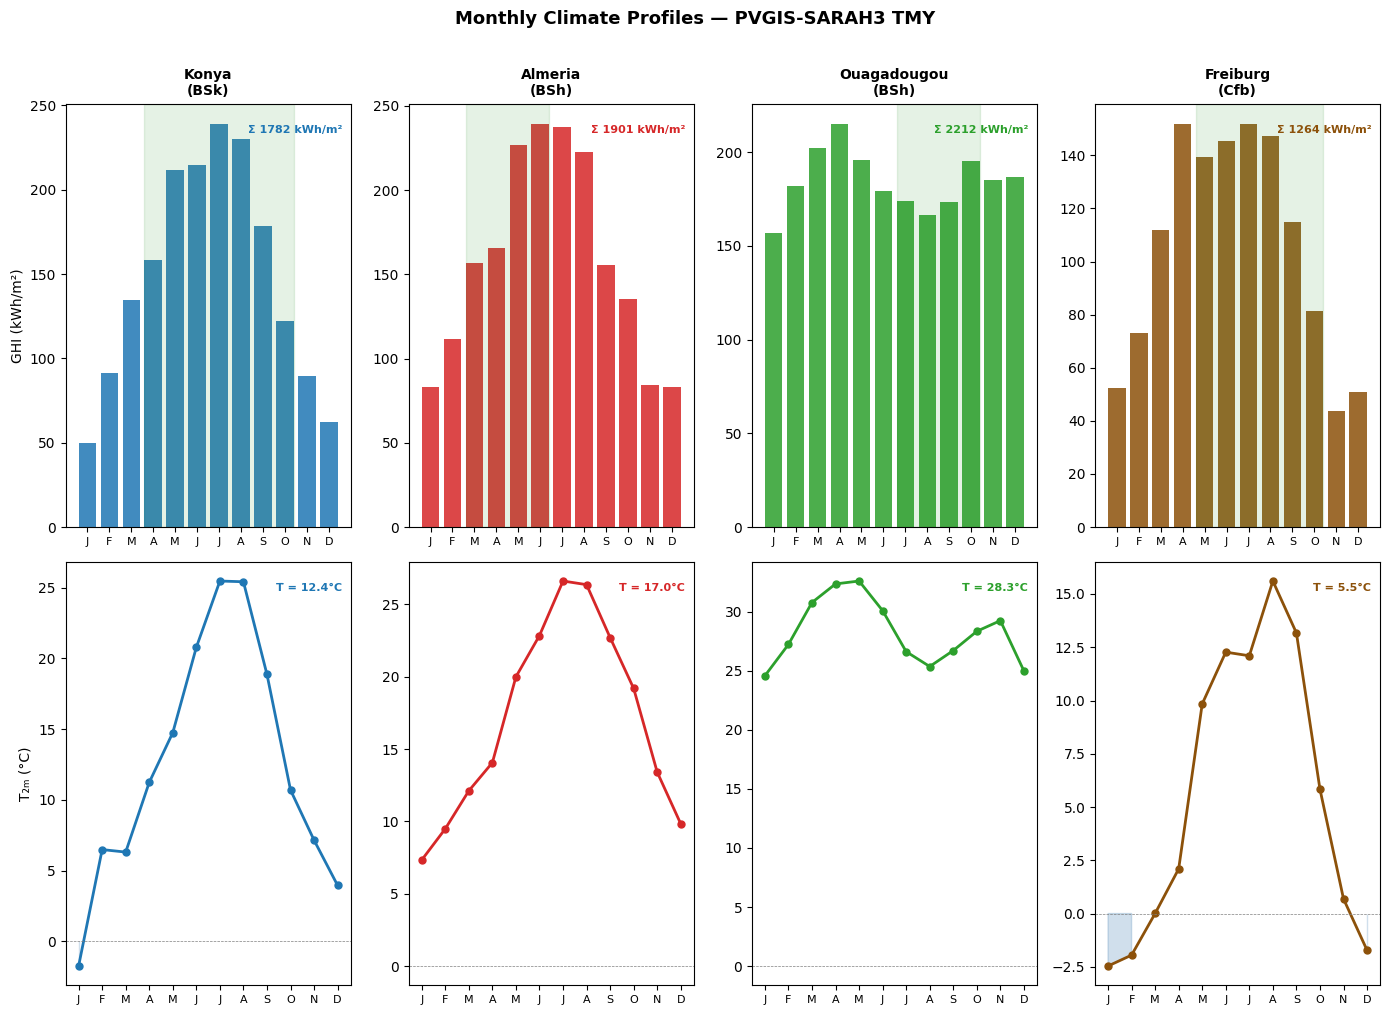

Figure saved → C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\figures\fig02_climate_profiles.png


In [9]:
# ── Figure 02: Monthly climate profiles (GHI + Temperature)
# Saved to outputs/figures/fig02_climate_profiles.png

fig, axes = plt.subplots(2, 4, figsize=FIG_STYLE["figsize_quad"])
fig.suptitle("Monthly Climate Profiles — PVGIS-SARAH3 TMY",
             fontsize=13, fontweight="bold", y=1.01)

site_list = list(TMY.keys())

for col, site in enumerate(site_list):
    df    = TMY[site]
    color = FIG_STYLE["site_colors"][site]
    idx   = pd.DatetimeIndex(df.index)

    # Monthly GHI (kWh/m²/month)
    monthly_ghi = df.groupby(idx.month)["GHI"].sum() / 1000
    ax_ghi = axes[0, col]
    ax_ghi.bar(monthly_ghi.index, monthly_ghi.values, color=color, alpha=0.85)
    ax_ghi.set_title(f"{site}\n({SITES[site]['koppen']})", fontsize=10, fontweight="bold")
    ax_ghi.set_ylabel("GHI (kWh/m²)" if col == 0 else "")
    ax_ghi.set_xticks(range(1, 13))
    ax_ghi.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"],
                            fontsize=8)
    ax_ghi.annotate(f"Σ {monthly_ghi.sum():.0f} kWh/m²",
                    xy=(0.97, 0.95), xycoords="axes fraction",
                    ha="right", va="top", fontsize=8, color=color, fontweight="bold")

    # Growing season shading on GHI plot
    cfg     = SITES[site]
    m_start = int(cfg["planting_date"].split("-")[0])
    m_end   = int(cfg["harvest_date"].split("-")[0])
    ax_ghi.axvspan(m_start - 0.4, m_end + 0.4, alpha=0.10,
                   color="green", label="Growing season")

    # Monthly T2m (°C)
    monthly_t = df.groupby(idx.month)["T2m"].mean()
    ax_t = axes[1, col]
    ax_t.plot(monthly_t.index, monthly_t.values,
              color=color, marker="o", linewidth=2, markersize=5)
    ax_t.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax_t.set_ylabel("T₂ₘ (°C)" if col == 0 else "")
    ax_t.set_xticks(range(1, 13))
    ax_t.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"],
                          fontsize=8)
    ax_t.annotate(f"T̄ = {monthly_t.mean():.1f}°C",
                  xy=(0.97, 0.95), xycoords="axes fraction",
                  ha="right", va="top", fontsize=8, color=color, fontweight="bold")
    ax_t.fill_between(monthly_t.index, monthly_t.values, 0,
                      where=monthly_t.values < 0,
                      color="steelblue", alpha=0.25, label="Below 0°C")

plt.tight_layout()
out_fig = FIG_DIR / "fig02_climate_profiles.png"
plt.savefig(out_fig, dpi=FIG_STYLE["dpi"], bbox_inches="tight")
plt.show()
print(f"Figure saved → {out_fig}")


In [10]:
print("\n" + "=" * 55)
print("  01_load_data — COMPLETE")
print("=" * 55)
print("\nFiles produced:")
for site in TMY:
    p = CSV_DIR / f"hourly_{site}.csv"
    print(f"  ✓ {p.name}")
p2 = FIG_DIR / "fig02_climate_profiles.png"
print(f"  ✓ {p2.name}")
print("\nNext step → open 02_simulation.ipynb")
print("=" * 55)



  01_load_data — COMPLETE

Files produced:
  ✓ hourly_Konya.csv
  ✓ hourly_Almeria.csv
  ✓ hourly_Ouagadougou.csv
  ✓ hourly_Freiburg.csv
  ✓ fig02_climate_profiles.png

Next step → open 02_simulation.ipynb
